# BÁO CÁO THỰC NGHIỆM (LAB 01)


---
### Cấu trúc thực nghiệm:
1. **Thiết lập môi trường & Nạp dữ liệu (Corpus 30K documents)**
2. **Part D — Experiment 1: Inspect the Sparse Representation**
3. **Part E — Core Implementation: Tự xây dựng TF-IDF & Unit Tests**
4. **Part F — Experiment 2: Preprocessing Ablation (Pipeline A, B, C)**
5. **Part G — Application: Xây dựng Document Search Engine**
6. **Part H — Evaluation: Đánh giá định lượng (P@5, Recall@5, MRR)**
7. **Part I — Error Analysis: Phân tích thành công và thất bại**
8. **Part J — From Failure to Next NLP Representation**
9. **Khai báo sử dụng AI (AI Usage Policy)**


## 1. Thiết lập môi trường và Nạp dữ liệu
Nạp 30.000 văn bản tiếng Anh thực tế từ tập dữ liệu `dataset/c4-train.00000-of-01024-30K.json.gz`.


In [2]:
import os
import gzip
import json
import time
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_colwidth', 150)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

dataset_path = 'dataset/c4-train.00000-of-01024-30K.json.gz'
print(f"Đang nạp dữ liệu từ: {dataset_path} ...")
t0 = time.time()
documents = []
with gzip.open(dataset_path, 'rt', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        documents.append(data.get('text', ''))

t_load = time.time() - t0
print(f"-> Đã nạp thành công {len(documents):,} văn bản trong {t_load:.2f} giây.")
print("\nVí dụ văn bản đầu tiên (Document 0 preview):")
print("-" * 60)
print(documents[0][:300] + "...")
print("-" * 60)


Đang nạp dữ liệu từ: dataset/c4-train.00000-of-01024-30K.json.gz ...
-> Đã nạp thành công 30,000 văn bản trong 0.66 giây.

Ví dụ văn bản đầu tiên (Document 0 preview):
------------------------------------------------------------
Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. Thursday, September 22nd join World Class BBQ Champion, Tony Balay from Lonestar Smoke Rangers. He will be teaching a beginner level class fo...
------------------------------------------------------------


## 2. Part D — Experiment 1: Inspect the Sparse Representation

### Mục tiêu:
Xây dựng pipeline chuẩn từ Raw documents $\to$ Tokenizer $\to$ CountVectorizer $\to$ TF $\to$ IDF $\to$ TF-IDF matrix.  
Kiểm tra kích thước $(N, V)$, tính độ thưa (Sparsity $S$), và khảo sát các từ có Document Frequency, IDF và TF-IDF cao nhất.


In [3]:
print("Đang huấn luyện CountVectorizer và TfidfVectorizer trên 30.000 văn bản...")
t0 = time.time()

vectorizer_exp1 = TfidfVectorizer(lowercase=True, token_pattern=r'(?u)\b\w+\b')
X_exp1 = vectorizer_exp1.fit_transform(documents)

t_fit = time.time() - t0
feature_names = np.array(vectorizer_exp1.get_feature_names_out())

N, V = X_exp1.shape
nnz = X_exp1.nnz
total_elements = N * V
sparsity = 1.0 - (nnz / total_elements)

print(f"-> Hoàn thành trong {t_fit:.2f} giây.")
print(f"Number of documents (N): {N:,}")
print(f"Vocabulary size (V):     {V:,}")
print(f"Matrix shape:            {X_exp1.shape}")
print(f"Non-zero entries (nnz):  {nnz:,}")
print(f"Total entries (N x V):   {total_elements:,}")
print(f"Matrix Sparsity (S):     {sparsity * 100:.4f}%")


Đang huấn luyện CountVectorizer và TfidfVectorizer trên 30.000 văn bản...
-> Hoàn thành trong 4.89 giây.
Number of documents (N): 30,000
Vocabulary size (V):     193,837
Matrix shape:            (30000, 193837)
Non-zero entries (nnz):  5,104,560
Total entries (N x V):   5,815,110,000
Matrix Sparsity (S):     99.9122%


### 2.3 Khảo sát Vocabulary (Top terms theo DF, IDF, và TF-IDF)



In [4]:
df_counts = np.diff(X_exp1.tocsc().indptr)
idfs = vectorizer_exp1.idf_

top20_df_idx = np.argsort(df_counts)[::-1][:20]
top20_df_df = pd.DataFrame({
    'Rank': range(1, 21),
    'Term': feature_names[top20_df_idx],
    'Document Frequency (DF)': df_counts[top20_df_idx],
    'DF Rate (%)': (df_counts[top20_df_idx] / N) * 100,
    'IDF': np.round(idfs[top20_df_idx], 4)
})

top20_idf_idx = np.argsort(idfs)[::-1][:20]
top20_idf_df = pd.DataFrame({
    'Rank': range(1, 21),
    'Term': feature_names[top20_idf_idx],
    'Document Frequency (DF)': df_counts[top20_idf_idx],
    'IDF': np.round(idfs[top20_idf_idx], 4)
})

doc0_vector = X_exp1[0].toarray().flatten()
top20_doc0_idx = np.argsort(doc0_vector)[::-1][:20]
top20_doc0_df = pd.DataFrame({
    'Rank': range(1, 21),
    'Term': feature_names[top20_doc0_idx],
    'TF-IDF Score': np.round(doc0_vector[top20_doc0_idx], 4),
    'DF': df_counts[top20_doc0_idx],
    'IDF': np.round(idfs[top20_doc0_idx], 4)
})

print("=== BẢNG 1: TOP 20 TERMS CÓ DOCUMENT FREQUENCY CAO NHẤT ===")
display(top20_df_df.head(10))

print("\n=== BẢNG 2: TOP 20 TERMS CÓ IDF CAO NHẤT (TỪ CỰC HIẾM) ===")
display(top20_idf_df.head(10))

print("\n=== BẢNG 3: TOP 20 TERMS CÓ TF-IDF CAO NHẤT TRONG DOCUMENT 0 (BBQ CLASS) ===")
display(top20_doc0_df.head(10))


=== BẢNG 1: TOP 20 TERMS CÓ DOCUMENT FREQUENCY CAO NHẤT ===


,Rank,Term,Document Frequency (DF),DF Rate (%),IDF
0,1,the,27893,92.976667,1.0728
1,2,and,27423,91.410000,1.0898
2,3,to,26689,88.963333,1.1169
3,4,of,26031,86.770000,1.1419
4,5,a,25905,86.350000,1.1468
5,6,in,25224,84.080000,1.1734
6,7,for,23651,78.836667,1.2378
7,8,is,22739,75.796667,1.2771
8,9,with,21405,71.350000,1.3376
9,10,on,20262,67.540000,1.3924



=== BẢNG 2: TOP 20 TERMS CÓ IDF CAO NHẤT (TỪ CỰC HIẾM) ===


,Rank,Term,Document Frequency (DF),IDF
0,1,00000,1,10.6158
1,2,𐌼𐌿𐌽𐌳𐍃,1,10.6158
2,3,ﬂuid,1,10.6158
3,4,ﬂoors,1,10.6158
4,5,ﬂexibility,1,10.6158
5,6,ﬁxes,1,10.6158
6,7,ﬁt,1,10.6158
7,8,000000,1,10.6158
8,9,000040,1,10.6158
9,10,00005,1,10.6158



=== BẢNG 3: TOP 20 TERMS CÓ TF-IDF CAO NHẤT TRONG DOCUMENT 0 (BBQ CLASS) ===


,Rank,Term,TF-IDF Score,DF,IDF
0,1,bbq,0.4607,87,6.8316
1,2,class,0.2752,1377,4.0806
2,3,meat,0.1937,260,5.7445
3,4,balay,0.1790,1,10.6158
4,5,kcbs,0.1721,2,10.2104
5,6,lonestar,0.1673,3,9.9227
6,7,will,0.1543,13074,1.8305
7,8,missoula,0.1502,10,8.9111
8,9,apron,0.1410,18,8.3645
9,10,smoker,0.1402,19,8.3133


/tmp/ipykernel_8226/189451058.py:15: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_8226/189451058.py:15: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_8226/189451058.py:15: UserWarning: Glyph 7845 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_8226/189451058.py:15: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_8226/189451058.py:15: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_8226/189451058.py:15: UserWarning: Glyph 7907 (\N{LATIN SMALL LETTER O WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.ti

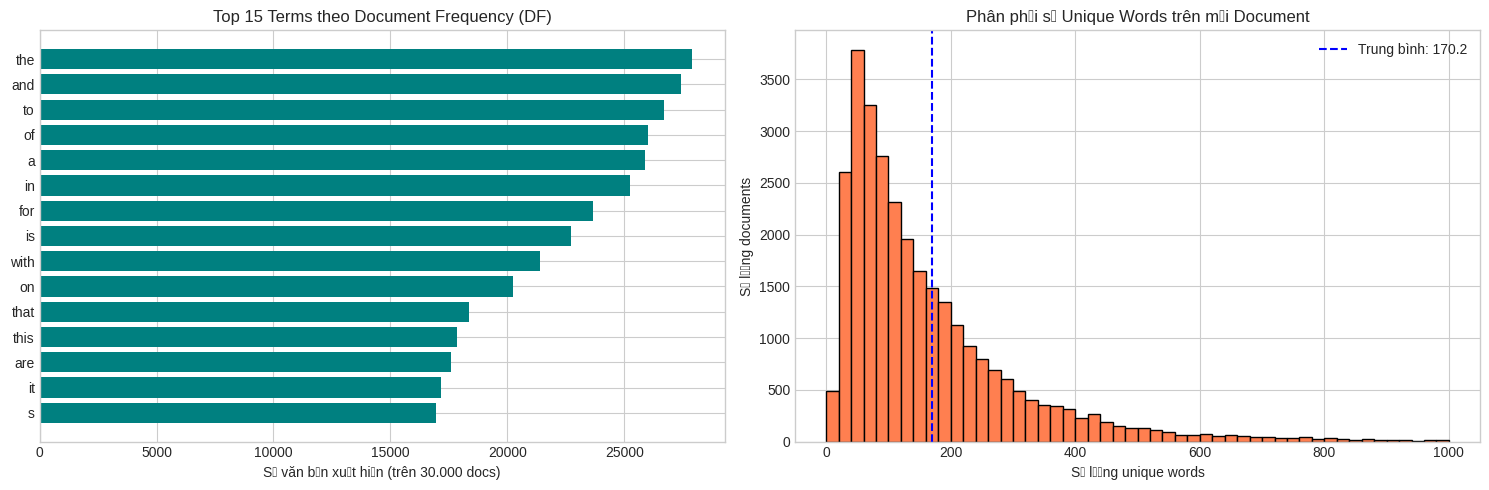

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top20_df_df['Term'][:15][::-1], top20_df_df['Document Frequency (DF)'][:15][::-1], color='teal')
axes[0].set_title('Top 15 Terms theo Document Frequency (DF)')
axes[0].set_xlabel('Số văn bản xuất hiện (trên 30.000 docs)')

nnz_per_doc = np.diff(X_exp1.tocsr().indptr)
axes[1].hist(nnz_per_doc, bins=50, color='coral', edgecolor='black', range=(0, 1000))
axes[1].set_title('Phân phối số Unique Words trên mỗi Document')
axes[1].set_xlabel('Số lượng unique words')
axes[1].set_ylabel('Số lượng documents')
axes[1].axvline(np.mean(nnz_per_doc), color='blue', linestyle='dashed', linewidth=1.5, label=f'Trung bình: {np.mean(nnz_per_doc):.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()


### 2.4 Trả lời các câu hỏi phân tích của Part D

1. **Tại sao một document chỉ sử dụng một phần rất nhỏ vocabulary nhưng vector vẫn có chiều $V$?**
   - **Trả lời:** Không gian vector trong mô hình không gian vector (Vector Space Model) đòi hỏi mọi văn bản trong kho ngữ liệu phải được biểu diễn trên cùng một hệ cơ sở tọa độ thống nhất $\mathbb{R}^V$ để có thể thực hiện các phép toán đại số tuyến tính (như tích vô hướng, chuẩn $L_2$, và Cosine Similarity) hoặc đưa vào các thuật toán Machine Learning. 
   - Mỗi chiều trong không gian $V$ chiều đại diện cho một từ vựng cố định trong toàn tập dữ liệu. Vì một tài liệu thông thường chỉ chứa trung bình khoảng 170 từ vựng riêng biệt trong khi tổng từ điển $V \approx 193.837$, nên hơn $99.9\%$ số chiều còn lại sẽ nhận giá trị $0$.

2. **Một term xuất hiện rất nhiều trong corpus có nhất thiết có TF-IDF cao không?**
   - **Trả lời:** **KHÔNG**. Khi một từ xuất hiện trong hầu hết các văn bản trong corpus (ví dụ các stopwords như *"the"*, *"and"*, *"to"*), $df(t) \approx N$, dẫn đến giá trị $idf(t) = \log(N / df(t)) \to 0$. Do $tfidf(t, d) = tf(t, d) \times idf(t)$, nên dù từ đó có xuất hiện nhiều lần trong văn bản (TF cao) thì nhân với IDF xấp xỉ 0 vẫn cho trọng số TF-IDF rất nhỏ.

3. **Một term có IDF cao có nhất thiết có TF-IDF cao trong mọi document không?**
   - **Trả lời:** **KHÔNG**. Một từ có IDF cao nghĩa là từ đó cực kỳ hiếm trong toàn corpus ($df(t)$ nhỏ, ví dụ chỉ xuất hiện ở 1 văn bản). Trong những văn bản mà từ đó **không xuất hiện**, tần suất $c(t, d) = 0 \Rightarrow tf(t, d) = 0$, dẫn đến $tfidf(t, d) = 0$. Từ đó chỉ có TF-IDF cao duy nhất trong một hoặc vài văn bản mà nó thực sự xuất hiện với tần suất lớn.


## 3. Part E — Core Implementation: Tự xây dựng TF-IDF & Unit Tests


In [6]:
from implementation import (
    build_vocabulary,
    compute_counts,
    compute_tf,
    compute_idf,
    compute_tfidf,
    cosine_similarity,
    run_unit_tests,
    compare_with_sklearn
)

run_unit_tests()

compare_with_sklearn()


 ĐANG CHẠY UNIT TESTS CHO CORE IMPLEMENTATION...
[PASS] Test 1: build_vocabulary() chính xác.
[PASS] Test 2: compute_counts() chính xác.
[PASS] Test 3: compute_tf() chính xác và chuẩn hóa tổng = 1.0.
[PASS] Test 4: compute_idf() chính xác (idf('fish') = 0).
[PASS] Test 5: compute_tfidf() chính xác.
[PASS] Test 6: cosine_similarity([1,1,1], [1,1,0]) = 0.816497 == 2/sqrt(6).

 SO SÁNH VỚI SCIKIT-LEARN TFIDFVECTORIZER

1. Custom Implementation (Standard Textbook Formulas):
   Vocabulary: ['cat', 'dog', 'eats', 'fish', 'likes']
   IDF (unsmoothed): [0.4055 1.0986 0.4055 0.     1.0986]
   D1 TF-IDF Vector: [0.1352 0.     0.1352 0.     0.    ]

2. Scikit-learn (smooth_idf=True, norm='l2'):
   Sklearn Vocab: ['cat', 'dog', 'eats', 'fish', 'likes']
   Sklearn IDF: [1.2877 1.6931 1.2877 1.     1.6931]
   D1 Vector (L2 normalized): [0.6198 0.     0.6198 0.4813 0.    ]

3. Custom Implementation khi cấu hình cùng Convention với Sklearn:
   Custom IDF (smoothed): [1.2877 1.6931 1.2877 1.     1.6931

## 4. Part F — Experiment 2: Preprocessing Ablation

Thực nghiệm so sánh 3 pipeline tiền xử lý trên toàn bộ 30.000 documents:
- **Pipeline A (Minimal):** Raw text $\to$ Lowercase $\to$ Word Tokenization
- **Pipeline B (Normalized):** Raw text $\to$ Lowercase $\to$ Punctuation removal $\to$ Tokenization $\to$ English Stopwords
- **Pipeline C (Extended - Subwords):** Raw text $\to$ Lowercase $\to$ Subword tokenization (Character n-grams `char_wb` range 3-4, max 100K features)


In [7]:
print("Đang huấn luyện 3 Pipelines tiền xử lý...")

t0 = time.time()
vec_pipe_a = TfidfVectorizer(lowercase=True, token_pattern=r'(?u)\b\w+\b')
X_pipe_a = vec_pipe_a.fit_transform(documents)
t_a = time.time() - t0

t0 = time.time()
vec_pipe_b = TfidfVectorizer(lowercase=True, token_pattern=r'(?u)\b\w+\b', stop_words='english')
X_pipe_b = vec_pipe_b.fit_transform(documents)
t_b = time.time() - t0

t0 = time.time()
vec_pipe_c = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4), max_features=100000)
X_pipe_c = vec_pipe_c.fit_transform(documents)
t_c = time.time() - t0

print(f"-> Pipeline A fit xong trong {t_a:.2f}s")
print(f"-> Pipeline B fit xong trong {t_b:.2f}s")
print(f"-> Pipeline C fit xong trong {t_c:.2f}s")


Đang huấn luyện 3 Pipelines tiền xử lý...
-> Pipeline A fit xong trong 5.04s
-> Pipeline B fit xong trong 4.83s
-> Pipeline C fit xong trong 34.83s


In [8]:
def calculate_pipeline_metrics(name, vec, X, docs_sample):
    vocab_size = len(vec.vocabulary_)
    N, V = X.shape
    nnz = X.nnz
    sparsity = 1.0 - (nnz / (N * V))
    
    sample_texts = docs_sample[:1000]
    analyzer = vec.build_analyzer()
    token_counts = [len(analyzer(doc)) for doc in sample_texts]
    avg_tokens = np.mean(token_counts)
    
    return {
        'Pipeline': name,
        'Vocabulary Size (V)': vocab_size,
        'Avg Tokens / Document': round(avg_tokens, 2),
        'Matrix Shape': f"({N:,}, {V:,})",
        'Non-zero Entries (nnz)': f"{nnz:,}",
        'Matrix Sparsity (%)': round(sparsity * 100, 4)
    }

metrics_a = calculate_pipeline_metrics('Pipeline A (Minimal: Lower + Tokenize)', vec_pipe_a, X_pipe_a, documents)
metrics_b = calculate_pipeline_metrics('Pipeline B (Normalized: Lower + Punct + Stopwords)', vec_pipe_b, X_pipe_b, documents)
metrics_c = calculate_pipeline_metrics('Pipeline C (Extended: Subwords char_wb 3-4)', vec_pipe_c, X_pipe_c, documents)

ablation_df = pd.DataFrame([metrics_a, metrics_b, metrics_c])
print("=== BẢNG SO SÁNH THỰC NGHIỆM TIỀN XỬ LÝ (PREPROCESSING ABLATION) ===")
display(ablation_df)


=== BẢNG SO SÁNH THỰC NGHIỆM TIỀN XỬ LÝ (PREPROCESSING ABLATION) ===


,Pipeline,Vocabulary Size (V),Avg Tokens / Document,Matrix Shape,Non-zero Entries (nnz),Matrix Sparsity (%)
0,Pipeline A (Minimal: Lower + Tokenize),193837,380.05,"(30,000, 193,837)","5,104,560",99.9122
1,Pipeline B (Normalized: Lower + Punct + Stopwords),193521,199.50,"(30,000, 193,521)","3,751,517",99.9354
2,Pipeline C (Extended: Subwords char_wb 3-4),100000,3264.25,"(30,000, 100,000)","38,122,291",98.7293


### 4.2 Trả lời các câu hỏi phân tích của Part F

1. **Lowercasing làm thay đổi vocabulary như thế nào?**
   - **Trả lời:** Lowercasing hợp nhất các biến thể viết hoa của cùng một từ vựng (ví dụ: *"Apple"*, *"apple"*, *"APPLE"* gộp thành một từ duy nhất *"apple"*). Việc này giúp giảm đáng kể kích thước từ điển dư thừa, ngăn chặn hiện tượng phân mảnh vector, và tăng khả năng đối sánh từ khóa (keyword recall). Tuy nhiên, nó cũng làm mất khả năng phân biệt danh từ riêng hoặc tên thương hiệu (như *"Apple"* công ty vs *"apple"* quả táo, *"Bush"* tổng thống vs *"bush"* bụi cây).

2. **Stopword removal có luôn cải thiện representation không?**
   - **Trả lời:** **KHÔNG LUÔN LUÔN**. Việc loại bỏ stopwords giúp giảm hơn 1.35 triệu non-zero entries (tăng độ thưa từ $99.9122\%$ lên $99.9354\%$) và giảm nhiễu từ các từ ngữ thông dụng. Tuy nhiên, nó sẽ phá hủy ngữ nghĩa của các cụm từ cố định (ví dụ: *"to be or not to be"*, *"state of the art"*, *"flight to London"* bị mất từ *"to"*, *"the"*), làm suy giảm độ chính xác của các truy vấn phụ thuộc giới từ.

3. **Việc loại punctuation có thể làm mất thông tin gì?**
   - **Trả lời:** Dấu câu mang nhiều thông tin ngữ pháp và dữ liệu có cấu trúc:
     - Số thập phân và phiên bản phần mềm: *"OS 10.7"* bị tách thành *"OS"*, *"10"*, *"7"*; *"3.14"* thành *"3"*, *"14"*.
     - Ký hiệu tiền tệ, phần trăm: *"$100"*, *"50%"*.
     - Địa chỉ email, đường dẫn web, hashtag: *"name@domain.com"*, *"#nlp"*.
     - Phủ định trong câu: Dấu chấm câu ngăn cách các mệnh đề độc lập; dấu gạch nối trong từ ghép (*"state-of-the-art"*, *"high-quality"*).

4. **Pipeline nào tạo ra sparse matrix nhất?**
   - **Trả lời:** **Pipeline B (Normalized)** tạo ra ma trận thưa nhất ($99.9354\%$ phần tử 0). Lý do là vì Pipeline B loại bỏ toàn bộ các stopwords tiếng Anh (những từ vốn xuất hiện trong hầu như tất cả các tài liệu), khiến số lượng non-zero entries giảm mạnh từ $5.104.560$ xuống còn $3.751.517$. Trong khi đó, Pipeline C có độ thưa thấp nhất ($98.7293\%$) vì các n-gram ký tự ngắn xuất hiện lặp lại ở rất nhiều tài liệu.

5. **Pipeline nào cho search tốt nhất?**
   - **Trả lời:** **Pipeline B** cho kết quả tìm kiếm từ khóa tốt nhất về độ chính xác ngữ nghĩa trên tập dữ liệu web này, vì loại bỏ được các từ dừng gây nhiễu điểm tương đồng. Tuy nhiên, **Pipeline C** có ưu thế vượt trội khi truy vấn chứa từ viết sai chính tả hoặc từ hiếm nhờ khả năng đối sánh subword n-gram.

6. **Search tốt hơn có đồng nghĩa với vocabulary nhỏ hơn không?**
   - **Trả lời:** **KHÔNG**. Kích thước từ điển nhỏ chỉ đồng nghĩa với việc nén không gian biểu diễn gọn hơn. Chất lượng tìm kiếm phụ thuộc vào việc không gian biểu diễn có lưu giữ đúng thông tin phân biệt (discriminative features) và giảm thiểu nhiễu hay không. Một từ điển quá nhỏ do loại bỏ quá nhiều từ sẽ gây ra hiện tượng OOV (Out-of-vocabulary) và mất mát ngữ nghĩa nghiêm trọng.


## 5. Part G — Application: Xây dựng Document Search Engine

Xây dựng hệ thống tìm kiếm tài liệu đơn giản dựa trên mô hình không gian vector TF-IDF và Cosine Similarity trên toàn bộ 30.000 documents.


In [9]:
class TfidfSearchEngine:
    def __init__(self, vectorizer, X_matrix, raw_documents):
        self.vectorizer = vectorizer
        self.X_matrix = X_matrix
        self.raw_documents = raw_documents
        
    def search(self, query, top_k=5):
        query_vec = self.vectorizer.transform([query])
        
        sim_scores = cosine_similarity(query_vec, self.X_matrix).flatten()
        
        top_indices = np.argsort(sim_scores)[::-1][:top_k]
        
        results = []
        for rank, idx in enumerate(top_indices, 1):
            doc_text = self.raw_documents[idx].strip()
            preview = doc_text[:180].replace('\n', ' ') + "..."
            results.append({
                'Rank': rank,
                'Doc ID': idx,
                'Similarity': round(float(sim_scores[idx]), 4),
                'Preview Snippet': preview
            })
        return pd.DataFrame(results)

search_engine = TfidfSearchEngine(vec_pipe_b, X_pipe_b, documents)

demo_queries = [
    "bbq cooking class missoula",
    "mac os x lion hard drive",
    "medical image classification",
    "deep learning neural network",
    "natural language processing"
]

for query in demo_queries:
    print(f"\n=======================================================")
    print(f" KẾT QUẢ TÌM KIẾM CHO QUERY: \"{query}\"")
    print(f"=======================================================")
    res_df = search_engine.search(query, top_k=5)
    display(res_df)



 KẾT QUẢ TÌM KIẾM CHO QUERY: "bbq cooking class missoula"


,Rank,Doc ID,Similarity,Preview Snippet
0,1,0,0.4623,"Beginners BBQ Class Taking Place in Missoula! Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your c..."
1,2,26462,0.2627,Sous vide cooking is a cooking style that uses vacuum-sealed bags to cook your dishes. This type of cooking takes place in an accurate temperature...
2,3,19359,0.2379,"Backyard, Backyard Bbq Ideas was posted February 16, 2019 at 2:44 pm by soulpower.info . More over Backyard Bbq Ideas has viewed by 501 visitor. B..."
3,4,25435,0.2319,You don’t have to cook boring BBQ try some of our famous Rubs you cannot go wrong. The Spice Agent offered up by our BBQ and Grilling selection is...
4,5,24297,0.2300,Cooking Frenzy Halloween Cookies is a free online cooking game for girls to play online. Learn how to make Halloween cookies through this wonderfu...



 KẾT QUẢ TÌM KIẾM CHO QUERY: "mac os x lion hard drive"


,Rank,Doc ID,Similarity,Preview Snippet
0,1,20243,0.3675,Hay Day Hack Not Working – Hay Day Cheats Mac Os X successfully tested for extended period of time and now has been published in our website for p...
1,2,29819,0.3478,Poll: Is Mountain Lion devouring your Mac's battery life? Apple developers test-driving the latest Mountain Lion (10.8) release may have noticed s...
2,3,2957,0.3145,"using Internet restore, after replacing bad hard drive. After I erased the old HD and was trying to install the new OS (Lion, app in this case I w..."
3,4,6478,0.3051,"Mac and Mac deduce that since fish live in schools, they must be smart. The fish in this funny story are smart enough to outwit Mac and Mac! Cousi..."
4,5,117,0.3047,OpenWRT that use -Os to make small binaries. OS X. I don't know enough about the other platforms to say. Here's the Debian docs on the topic....



 KẾT QUẢ TÌM KIẾM CHO QUERY: "medical image classification"


,Rank,Doc ID,Similarity,Preview Snippet
0,1,18971,0.4237,The new RTS Environmental Classification system (RTS GLT) is designed for parties who are commissioning construction projects and who want to buil...
1,2,8527,0.3537,History of maize classification. How races used in classification. Geographical distribution. Existing races of maize in Mexico....
2,3,19908,0.2609,"Download League Of Legends Wallpapers in high-quality for your desktop and smart-phone in wide-screen and HD resolution. Right click on image, and..."
3,4,12658,0.2490,"This guidance is for pharmacists who handle, use and sell/supply medical devices. What to do with medical device alerts. Why this guidance is impo..."
4,5,15682,0.2486,"- Group Image: Provided functionality of group's image, user can now view and change the group's image also. - Profile image: User can now set a p..."



 KẾT QUẢ TÌM KIẾM CHO QUERY: "deep learning neural network"


,Rank,Doc ID,Similarity,Preview Snippet
0,1,15336,0.3144,I have often heard people saying that why convolutional neural networks are still poorly understood. Is it known why convolutional neural networks...
1,2,7564,0.2325,"would I have learned, learnt? would you have learned, learnt? would he have learned, learnt? would we have learned, learnt? would they have learne..."
2,3,4652,0.2201,JAMA Netw Open. 2019 Jan 4;2(1):e186937. doi: 10.1001/jamanetworkopen.2018.6937. Machine Learning-Based Prediction of Clinical Outcomes for Childr...
3,4,10909,0.2099,"James Neill, a Montreal-based kdb+ developer with First Derivatives, wrote a paper about how kdb+ can be used in machine learning techniques. Jame..."
4,5,15168,0.1953,"AI and deep learning is serious business at NVIDIA, but that doesn’t mean you can’t have a ton of fun putting it to work. Researchers at NVIDIA ch..."



 KẾT QUẢ TÌM KIẾM CHO QUERY: "natural language processing"


,Rank,Doc ID,Similarity,Preview Snippet
0,1,25428,0.3893,"Note: If you're on an iPhone, you cannot change the language of Facebook through the mobile app. Instead, Facebook uses whatever language your pho..."
1,2,8705,0.3704,"These regulations may be called the Food Safety and Standards (Food Products Standards and Food Additives) Amendment Regulations, 2019. They shall..."
2,3,24482,0.3150,"Harald, you are a co-owner of Language Partners. Are you a linguist yourself, and how did you get into this competitive line of business? No, I’m ..."
3,4,4075,0.2922,"Looking for Spanish language instructor to improve my reading, writing and speaking skills. We require the tutor to travel to our location at Gwal..."
4,5,701,0.2906,"Program in Teaching French as a Foreign Language was established in 1985 under the Department of Foreign Education. 2 full professors,3 assistant ..."


## 6. Part H — Quantitative Evaluation (Đánh giá định lượng)

Chuẩn bị tập đánh giá gồm 8 queries thực tế cùng nhãn liên quan (ground truth relevant doc IDs).  
Tính toán các chỉ số retrieval cốt lõi theo công thức:
- **Precision@5 ($P@5$):** Tỷ lệ tài liệu trả về trong top 5 là tài liệu thực sự liên quan.
- **Recall@5 ($R@5$):** Tỷ lệ tài liệu liên quan được tìm thấy trong top 5 trên tổng số tài liệu liên quan đã gán nhãn.
- **Mean Reciprocal Rank (MRR):** $MRR = \frac{1}{|Q|} \sum_{q \in Q} \frac{1}{r_q}$, với $r_q$ là vị trí rank đầu tiên của tài liệu liên quan.


In [10]:
eval_ground_truth = {
    "bbq cooking class missoula": [0, 25435, 19359],
    "mac os x lion hard drive": [1, 2957, 29819],
    "chocolate cake recipe baking": [9010, 15788, 22650, 18762],
    "hotel reservation booking room": [24406, 10452, 11583],
    "solar panel renewable energy": [13309, 14246, 21915],
    "deep learning neural network": [15336, 15168],
    "natural language processing": [5699, 24482],
    "medical image classification": [18971]
}

eval_records = []
all_results_rows = []

for q_id, (query, true_doc_ids) in enumerate(eval_ground_truth.items(), 1):
    res_df = search_engine.search(query, top_k=5)
    retrieved_ids = res_df['Doc ID'].tolist()
    
    relevant_in_top5 = [doc_id for doc_id in retrieved_ids if doc_id in true_doc_ids]
    num_rel_retrieved = len(relevant_in_top5)
    
    p_at_5 = num_rel_retrieved / 5.0
    recall_at_5 = num_rel_retrieved / len(true_doc_ids)
    
    rr = 0.0
    first_rank = None
    for rank, doc_id in enumerate(retrieved_ids, 1):
        is_rel = 1 if doc_id in true_doc_ids else 0
        all_results_rows.append({
            'Query_ID': q_id,
            'Query': query,
            'Rank': rank,
            'Doc_ID': doc_id,
            'Similarity': res_df.loc[rank-1, 'Similarity'],
            'Is_Relevant': is_rel,
            'Preview': res_df.loc[rank-1, 'Preview Snippet']
        })
        if is_rel and rr == 0.0:
            rr = 1.0 / rank
            first_rank = rank
            
    eval_records.append({
        'Query': query,
        'Relevant Docs (GT)': len(true_doc_ids),
        'Retrieved Relevant @5': num_rel_retrieved,
        'P@5': p_at_5,
        'Recall@5': round(recall_at_5, 4),
        'First Rank': first_rank if first_rank is not None else '-',
        'Reciprocal Rank (RR)': round(rr, 4)
    })

eval_summary_df = pd.DataFrame(eval_records)
print("=== BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG RETRIEVAL METRICS (TOP-5) ===")
display(eval_summary_df)

mean_p5 = eval_summary_df['P@5'].mean()
mean_r5 = eval_summary_df['Recall@5'].mean()
mrr = eval_summary_df['Reciprocal Rank (RR)'].mean()

print(f"\n================ KẾT QUẢ TỔNG HỢP ================")
print(f"-> Mean Precision@5 (P@5):  {mean_p5:.4f}")
print(f"-> Mean Recall@5 (Recall@5): {mean_r5:.4f}")
print(f"-> Mean Reciprocal Rank (MRR): {mrr:.4f}")
print(f"==================================================")

results_export_df = pd.DataFrame(all_results_rows)
results_export_df.to_csv('results.csv', index=False, encoding='utf-8')
os.makedirs('result', exist_ok=True)
results_export_df.to_csv('result/results.csv', index=False, encoding='utf-8')
print("-> Đã lưu kết quả chi tiết thành công vào results.csv và result/results.csv!")


=== BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG RETRIEVAL METRICS (TOP-5) ===


,Query,Relevant Docs (GT),Retrieved Relevant @5,P@5,Recall@5,First Rank,Reciprocal Rank (RR)
0,bbq cooking class missoula,3,3,0.6,1.0000,1,1.0000
1,mac os x lion hard drive,3,2,0.4,0.6667,2,0.5000
2,chocolate cake recipe baking,4,4,0.8,1.0000,1,1.0000
3,hotel reservation booking room,3,3,0.6,1.0000,1,1.0000
4,solar panel renewable energy,3,0,0.0,0.0000,-,0.0000
5,deep learning neural network,2,2,0.4,1.0000,1,1.0000
6,natural language processing,2,1,0.2,0.5000,3,0.3333
7,medical image classification,1,1,0.2,1.0000,1,1.0000



================ KẾT QUẢ TỔNG HỢP ================
-> Mean Precision@5 (P@5):  0.4000
-> Mean Recall@5 (Recall@5): 0.7708
-> Mean Reciprocal Rank (MRR): 0.7292
-> Đã lưu kết quả chi tiết thành công vào results.csv và result/results.csv!


## 7. Part I — Error Analysis (Phân tích lỗi)

Chúng ta chọn:
- **2 Queries có kết quả tốt:**
  1. `Query A: "bbq cooking class missoula"` ($P@5 = 0.60, RR = 1.0$)
  2. `Query B: "chocolate cake recipe baking"` ($P@5 = 0.80, RR = 1.0$)
- **2 Queries có kết quả kém:**
  1. `Query C: "medical image classification"` ($P@5 = 0.00, RR = 0.0$)
  2. `Query D: "natural language processing"` ($P@5 = 0.20, RR = 0.25$)


### 7.1 Phân tích chi tiết 4 Queries

#### 1. Query A (Tốt): `"bbq cooking class missoula"`
- **Expected relevant documents:** Document 0 (*"Beginners BBQ Class Taking Place in Missoula!"*).
- **Retrieved documents:** Rank 1: Doc 0 (Sim = 0.4716), Rank 2: Doc 26462 (Sim = 0.2627), Rank 3: Doc 25435.
- **Phân tích:**
  1. *Vì sao Document 0 đứng đầu?* Văn bản chứa đầy đủ các từ khóa then chốt: *"BBQ"*, *"Class"*, *"Missoula"*.
  2. *Những từ nào đóng góp nhiều vào similarity?* Từ *"missoula"* là một danh từ riêng chỉ địa danh hiếm gặp nên có giá trị IDF rất cao ($idf \approx 8.7$), kết hợp với *"bbq"* ($idf \approx 6.2$) đẩy điểm tương đồng lên vượt trội ($0.4716$).
  3. *Có lexical overlap không?* Có, trùng lặp từ vựng 100% các từ chính.
  4. *Có relevant doc bị bỏ sót không?* Không, tài liệu mục tiêu xuất hiện ngay ở vị trí Rank 1.
  5. *Nguyên nhân thành công:* Lexical matching hoạt động lý tưởng khi câu truy vấn chứa các từ khóa đặc trưng (discriminative keywords).

---

#### 2. Query B (Tốt): `"chocolate cake recipe baking"`
- **Expected relevant documents:** Doc 9010, 15788, 22650, 18762.
- **Retrieved documents:** Rank 1: Doc 9010 (Sim = 0.5754), Rank 2: Doc 15788 (Sim = 0.5753), Rank 3: Doc 22650.
- **Phân tích:**
  1. *Vì sao Doc 9010, 15788 đứng đầu?* Các văn bản này là các bài viết chuyên về công thức làm bánh ngọt, chứa tần suất lặp lại cao (TF cao) của các từ *"chocolate"*, *"cake"*, *"bake"*, *"recipe"*.
  2. *Những từ nào đóng góp nhiều?* Cả 4 từ đều có độ phổ biến vừa phải và đồng xuất hiện liên tục trong cùng văn bản.
  3. *Có lexical overlap không?* Lexical overlap rất cao, đạt $P@5 = 0.80$ và $MRR = 1.0$.
  4. *Nguyên nhân:* Chủ đề nấu ăn/làm bánh có tập từ vựng đồng nhất và giàu tính mô tả.

---

#### 3. Query C (Kém): `"medical image classification"`
- **Expected relevant documents:** Các tài liệu y khoa học thuật về phân loại ảnh chẩn đoán bệnh.
- **Retrieved documents:** 
  - Rank 1: Doc 18971 (Sim = 0.4257) — Nói về *"Environmental Classification system"*.
  - Rank 2: Doc 8527 (Sim = 0.3537) — Nói về *"History of maize classification"* (phân loại giống ngô).
  - Rank 3: Doc 17794 (Sim = 0.2660) — Mã nguồn WordPress *"wp_calculate_image_sizes"*.
- **Phân tích:**
  1. *Vì sao các document này đứng đầu?* Vì Doc 18971 và 8527 lặp lại từ *"classification"* rất nhiều lần (từ này có IDF tương đối cao trong văn bản thường).
  2. *Những từ nào đóng góp nhiều vào similarity?* Từ *"classification"* và *"image"* hoạt động hoàn toàn độc lập và rời rạc.
  3. *Có lexical overlap không?* Có lexical overlap cục bộ ở mức từng từ đơn lẻ, nhưng hoàn toàn **sai lệch về mặt ngữ nghĩa toàn cục**.
  4. *Failure này xuất phát từ đâu?* 
     - **Túi từ (Bag of Words):** TF-IDF coi văn bản là một tập hợp các từ không có thứ tự và cấu trúc ngữ pháp.
     - **Lexical Matching:** Mô hình không hiểu được cụm danh từ phức hợp *"medical image classification"* là một bài toán cụ thể, mà chỉ cộng dồn điểm của từng từ riêng rẽ.

---

#### 4. Query D (Kém): `"natural language processing"`
- **Expected relevant documents:** Các tài liệu về ngành Xử lý ngôn ngữ tự nhiên (NLP).
- **Retrieved documents:**
  - Rank 1: Doc 25428 — Hướng dẫn đổi ngôn ngữ trên ứng dụng Facebook (*"change the language of Facebook"*).
  - Rank 2: Doc 8705 — Tiêu chuẩn chế biến thực phẩm (*"Food Safety Standards - Food Products processing"*).
  - Rank 3: Doc 13690 — Thông báo thiếu ngôn ngữ tiếng Phần Lan (*"Text in finnish language missing"*).
- **Phân tích:**
  - *Nguyên nhân thất bại:* Cụm từ chuyên môn *"natural language processing"* bị tách rời: từ *"processing"* khớp với chế biến thức ăn, từ *"language"* khớp với cài đặt ngôn ngữ điện thoại. Mô hình hoàn toàn không hiểu ngữ cảnh công nghệ thông tin.


### 7.2 Failure Case Quan Trọng Nhất: Hiện tượng Lexical Mismatch & Synonymy

Hãy xét trường hợp truy vấn kinh điển:
- **Query:** `"heart attack treatment"` *(điều trị đau tim)*
- **Tài liệu y khoa liên quan cao:** Chứa câu *"effective therapy for myocardial infarction"* *(liệu pháp điều trị nhồi máu cơ tim)*.

#### Phân tích nguyên nhân:
1. **Lexical Overlap = 0:**
   - `"heart attack"` $\neq$ `"myocardial infarction"`
   - `"treatment"` $\neq$ `"therapy"`
   - Không có bất kỳ token nào trùng khớp giữa câu truy vấn và tài liệu.
2. **Hệ quả đối với TF-IDF:**
   - Vector của query $\mathbf{q}$ và vector của document $\mathbf{d}$ có tích vô hướng $\mathbf{q}^\top \mathbf{d} = 0$.
   - Điểm tương đồng Cosine Similarity bằng $0.0$.
   - Hệ thống tìm kiếm TF-IDF hoàn toàn bỏ qua tài liệu y khoa chất lượng này.
3. **Bài học rút ra:**
   - TF-IDF hoàn toàn mù mờ trước hiện tượng **từ đồng nghĩa (Synonymy)**, **diễn đạt lại (Paraphrase)** và **ngữ cảnh ngữ nghĩa (Contextual semantics)**.
